In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, zero_one_loss, accuracy_score


from copy import deepcopy

## Generación de datos

In [4]:
# Diagonales

def diagonales(n, d, C):
  mean0 = np.full(d,-1)
  mean1 = np.full(d,1)
    
  desviacion_std = C * np.sqrt(d)
  covarianza = np.diag(np.full(d,desviacion_std)**2)
    
  input0 = np.random.multivariate_normal(mean0, covarianza, n//2)
  input1 = np.random.multivariate_normal(mean1, covarianza, n//2)
    
  output0 = np.full(n//2, 0)  
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0, output1]).tolist()


# Paralelas

def paralelas(n, d, C):
  mean0 = np.zeros(d)
  mean1 = np.zeros(d)
  mean0[0] = 1
  mean1[0] = -1

  desviacion_std = C
  covarianza = np.diag(np.full(d,desviacion_std)**2)
    
  input0 = np.random.multivariate_normal(mean0, covarianza, n//2)
  input1 = np.random.multivariate_normal(mean1, covarianza, n//2)
    
  output0 = np.full(n//2, 0)  
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0, output1]).tolist()


# Espirales

def toCartesianP(r, theta):
  x = r * np.cos(theta)
  y = r * np.sin(theta)
  return (x, y)

def toCartesianA(rs, thetas):
  a = [(r * np.cos(theta), r * np.sin(theta)) for r, theta in zip(rs, thetas)]
  return a

def espirales(n):
  r0s = np.sqrt(np.random.uniform(0, 1, n//2))  
  a0s = np.random.uniform(0, 1, n//2)
  theta0s = [np.pi*(4*r-a) for r,a in zip(r0s,a0s)]

  r1s = np.sqrt(np.random.uniform(0, 1, n//2))
  a1s = np.random.uniform(-1, 0, n//2)
  theta1s = [np.pi*(4*r-a) for r,a in zip(r1s,a1s)]

  input0 = toCartesianA(r0s,theta0s)
  input1 = toCartesianA(r1s,theta1s)

  output0 = np.full(n//2, 0)
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0,output1]).tolist()

## Definimos nuestras redes

In [5]:
# Parámetros
"""
Comenzar y frenar el entrenamiento de una red es costoso, por lo que no
mediremos las métricas una vez por época, sino que haremos varias épocas a la
vez. Por ésto definimos sub-épocas, por ejemplo como 10, para realizar 10 épocas
a la vez y luego medir las métricas de error.
"""
sub_epocas=10   # numero de epocas que entrena cada vez
super_epocas=100 # numero de veces que realizaremos sub-epocas
# epocas ~= sub_epocas * super_epocas
eta=0.01        # learning rate
alfa=0.9        # momentum
N2=4            # neuronas en la capa oculta

In [6]:
# Defino MLP para regresión
def Regressor():
    return MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa,nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)   

print(Regressor())

MLPRegressor(activation='logistic', alpha=0.0, batch_size=1,
             hidden_layer_sizes=(4,), learning_rate_init=0.01, max_iter=10,
             nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


In [7]:
# Defino MLP para clasificación
def Classifier():
    return MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(Classifier())

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(4,), learning_rate_init=0.01, max_iter=10,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


## Funcion de entrenamiento

In [8]:
def entrenar_red(red: MLPClassifier | MLPRegressor,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "super_epocas" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    

    evaluaciones = super_epocas

    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(mean_squared_error(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = mean_squared_error(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test

## Ejercicio 1

In [7]:
eta = 0.1
alfa = 0.9
N2s = [2, 10, 20, 40]
sub_epocas = 20#1000
super_epocas = 1000#20

X_test, Y_test = espirales(2000)

df = {
    2: {},
    10: {},
    20: {},
    40: {}
}

for N2 in N2s:
    cla = Classifier()
    display(cla)
    train = espirales(600)
    X_train,X_val,Y_train,Y_val = skl.model_selection.train_test_split(train[0], train[1], test_size=0.2)
    best_fit, train_error, val_error, test_error = entrenar_red(cla, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    Y_ans = best_fit.predict(X_test)
    df[N2] = {"input": X_test, "output": Y_ans, "train_error": train_error, "val_error": val_error, "test_error": test_error}

df = pd.DataFrame.from_dict(df)

display(df)

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(2,), learning_rate_init=0.1, max_iter=20,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(10,), learning_rate_init=0.1, max_iter=20,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(20,), learning_rate_init=0.1, max_iter=20,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the opti

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(40,), learning_rate_init=0.1, max_iter=20,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the opti

,2,10,20,40
input,"[[-0.42402068015166067, 0.029660365755851643],...","[[-0.42402068015166067, 0.029660365755851643],...","[[-0.42402068015166067, 0.029660365755851643],...","[[-0.42402068015166067, 0.029660365755851643],..."
output,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, ...","[0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, ..."
train_error,"[0.41874999999999996, 0.43125, 0.4562500000000...","[0.4291666666666667, 0.43333333333333335, 0.43...","[0.44375, 0.39375000000000004, 0.4125, 0.39166...","[0.4041666666666667, 0.4041666666666667, 0.429..."
val_error,"[0.44166666666666665, 0.44166666666666665, 0.4...","[0.4666666666666667, 0.4, 0.4, 0.3916666666666...","[0.43333333333333335, 0.4, 0.475, 0.4, 0.44999...","[0.4833333333333333, 0.4916666666666667, 0.441..."
test_error,"[0.4345, 0.4425, 0.46699999999999997, 0.444999...","[0.45599999999999996, 0.43600000000000005, 0.4...","[0.46799999999999997, 0.4285, 0.43700000000000...","[0.44599999999999995, 0.4295, 0.44599999999999..."


Ahora graficamos las predicciones

/tmp/ipykernel_7897/2513521291.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


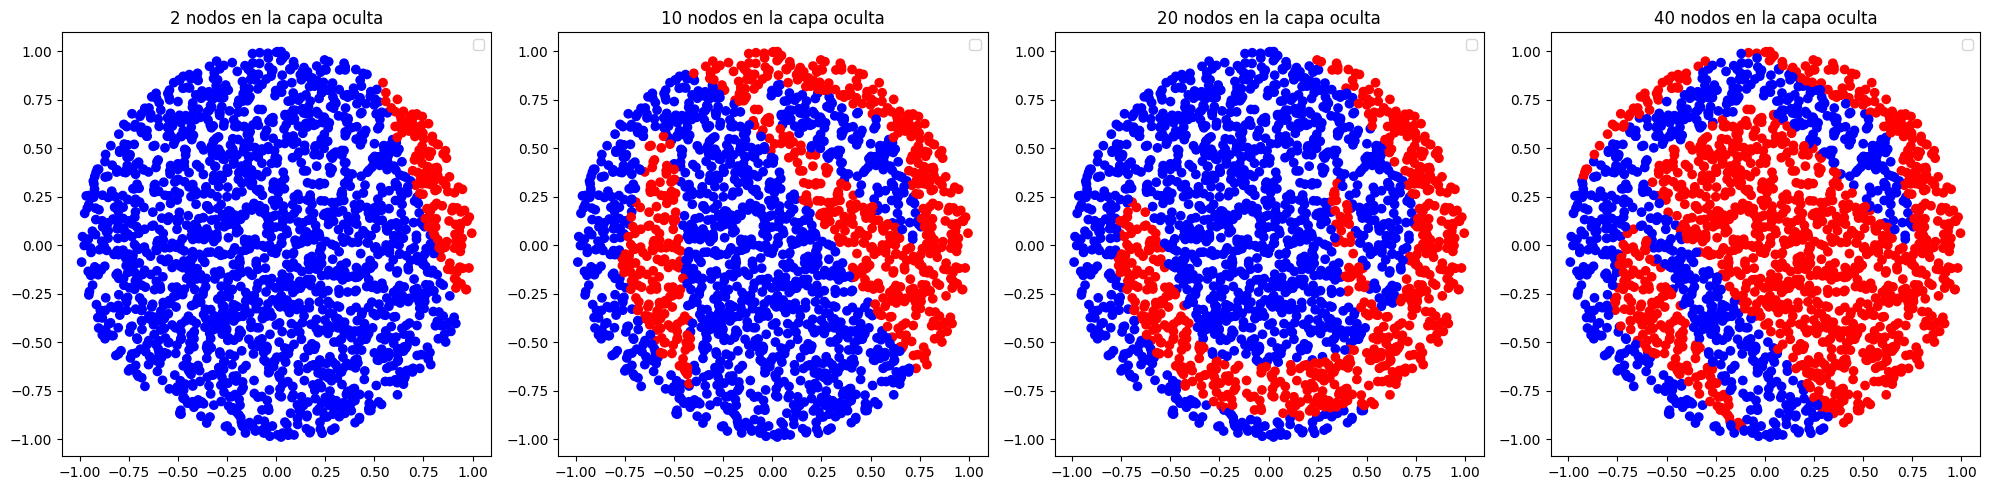

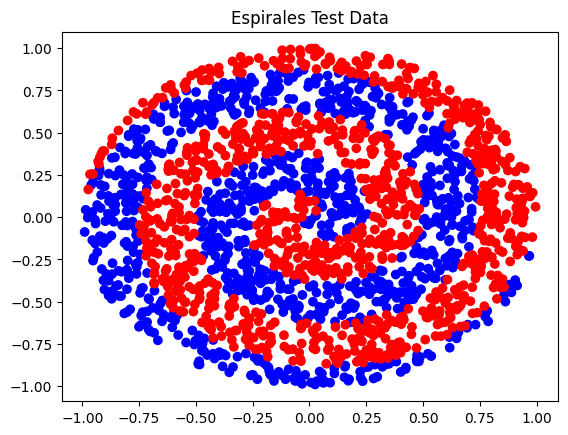

In [8]:
def plotEspiral(dd):
    N2s = df.keys()
    fig, axs = plt.subplots(1, len(N2s), figsize=(20, 5))
    for N2, ax in zip(N2s, axs):
        X = df[N2]["input"]
        Y = df[N2]["output"]
        ax.scatter([x[0] for x in X], [x[1] for x in X], c=Y, cmap="bwr")
        ax.set_title("{} nodos en la capa oculta".format(N2))
        ax.legend()
    plt.tight_layout()
    plt.show()

plotEspiral(df)

plt.scatter([x[0] for x in X_test], [x[1] for x in X_test], c=Y_test, cmap="bwr")
plt.title("Espirales Test Data")
plt.show()

## Ejercicio 2

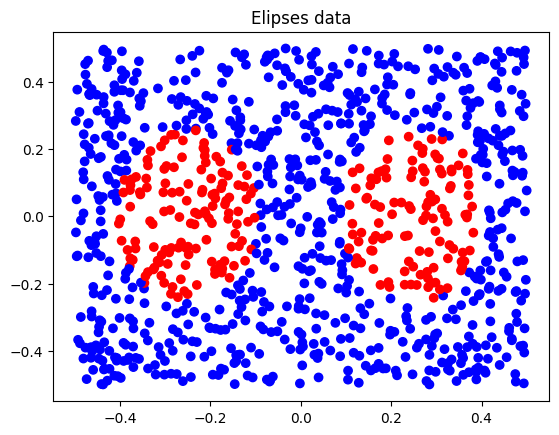

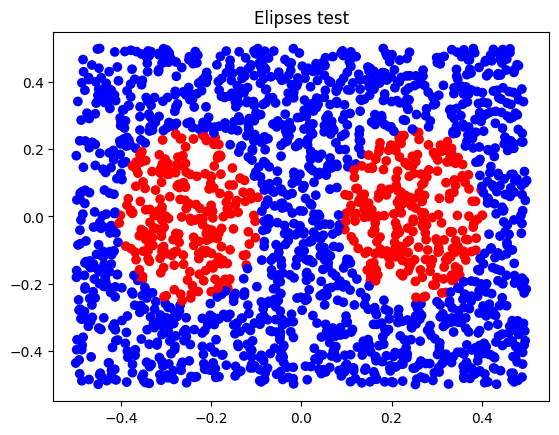

In [24]:
def cargar_csv(path, xcols=2):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
    """
    df = pd.read_csv(path, header=None)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

def plot_elipses(data):
    p = data[0]
    c = data[1]

    plt.scatter(p[0], p[1], c=c, cmap="bwr")
    plt.show()

data = cargar_csv("dos_elipses.data")

plt.title("Elipses data")
plot_elipses(data)

test = cargar_csv("dos_elipses.test")
plt.title("Elipses test")
plot_elipses(test)

Entreno los perceptrones

In [ ]:
N2 = 6
super_epocas = 300
sub_epocas = 50

TRAINS = 10

error = []

# Probar diferentes momentos y learning rates

# Elegir un momento
#alfa = 0.5

# Elegir un learning rate
#eta = 0.1

alfas = [0,0.5,0.9]
etas = [0.1, 0.01, 0.001]

for alfa,eta in zip(alfas, etas):
    for i in range(TRAINS):
        # Elegir 500 valores del conjunto de data
        X_data,_,Y_data,_ = skl.model_selection.train_test_split(data[0].values.tolist(), data[1].values.tolist(), train_size=500)
        X_train, X_val, Y_train, Y_val = skl.model_selection.train_test_split(X_data,Y_data, train_size=400)

        # Elegir 2000 valores del conjunto de test
        # test ya tiene 2000 elementos
        _,X_test,_,Y_test = skl.model_selection.train_test_split(test[0].values.tolist(), test[1].values.tolist())

        cla = Classifier()

        best_fit, *_ = entrenar_red(cla,X_train,Y_train,X_val,Y_val,X_test,Y_test)
    
        error.append(1-accuracy_score(Y_test, best_fit.predict(X_test)))

    print("Alfa:", alfa, "Eta:", eta)
    print("Error de test:", np.mean(error)*100)
    print("\n")


/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Alfa: 0 Eta: 0.1
Error de test: 23.86


Alfa: 0.5 Eta: 0.01
Error de test: 23.849999999999998


Alfa: 0.9 Eta: 0.001
Error de test: 24.233333333333334




## Ejercicio 3

In [19]:
column_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
data = pd.read_csv('ikeda.data', delim_whitespace=True, header=None, names=column_names)
test = pd.read_csv('ikeda.test', delim_whitespace=True, header=None, names=column_names)

display(data)
display(test)

TRAINS = 10

eta = 0.01
alfa = 0.9
super_epocas = 400
sub_epocas = 50
N2 = 30

PORCENTAJE_TRAIN = [0.95, 0.75, 0.5]

df = {
    0.95: {},
    0.75: {},
    0.5: {}
}

# Elegir 2000 valores del conjunto de test
_, X_test, _, Y_test = skl.model_selection.train_test_split(test.iloc[:, :-1].values.tolist(), test.iloc[:, -1].values.tolist(),test_size=2000)


for p in PORCENTAJE_TRAIN:
    etrain = []
    eeval = []
    etest = []

    # Elegir valores del conjunto de data
    X_train, X_val, Y_train, Y_val = skl.model_selection.train_test_split(data.iloc[:, :-1].values.tolist(), data.iloc[:, -1].values.tolist(), train_size=p)

    for i in range(TRAINS):
        reg = Regressor()

        best_fit, *_ = entrenar_red(reg, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    
        etrain.append(mean_squared_error(Y_train, best_fit.predict(X_train)))
        eeval.append(mean_squared_error(Y_val, best_fit.predict(X_val)))
        etest.append(mean_squared_error(Y_test, best_fit.predict(X_test)))

    df[p] = {
        "train_error": etrain,
        "val_error": eeval,
        "test_error": etest
    }

df = pd.DataFrame.from_dict(df)

/tmp/ipykernel_13770/3251587475.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('ikeda.data', delim_whitespace=True, header=None, names=column_names)
/tmp/ipykernel_13770/3251587475.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  test = pd.read_csv('ikeda.test', delim_whitespace=True, header=None, names=column_names)


,x1,x2,x3,x4,x5,x6
0,0.907938,0.580088,0.165603,0.701732,0.354170,0.976418
1,0.580088,0.165603,0.701732,0.354170,0.976418,0.464438
2,0.165603,0.701732,0.354170,0.976418,0.464438,0.462873
3,0.701732,0.354170,0.976418,0.464438,0.462873,0.447031
4,0.354170,0.976418,0.464438,0.462873,0.447031,1.023614
...,...,...,...,...,...,...
95,0.590963,0.408041,0.921964,0.443131,0.614752,0.556577
96,0.408041,0.921964,0.443131,0.614752,0.556577,0.437420
97,0.921964,0.443131,0.614752,0.556577,0.437420,0.419920
98,0.443131,0.614752,0.556577,0.437420,0.419920,1.114815


,x1,x2,x3,x4,x5,x6
0,0.498048,0.655449,0.342761,1.138024,0.678734,-0.081692
1,0.655449,0.342761,1.138024,0.678734,-0.081692,1.052985
2,0.342761,1.138024,0.678734,-0.081692,1.052985,0.204229
3,1.138024,0.678734,-0.081692,1.052985,0.204229,1.299434
4,0.678734,-0.081692,1.052985,0.204229,1.299434,1.222963
...,...,...,...,...,...,...
4795,0.849172,0.382464,0.975345,0.951475,0.031079,1.018942
4796,0.382464,0.975345,0.951475,0.031079,1.018942,1.296063
4797,0.975345,0.951475,0.031079,1.018942,1.296063,0.579384
4798,0.951475,0.031079,1.018942,1.296063,0.579384,-0.150451


/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the opti

,0.95,0.75,0.50
train_error,"[0.05476239015438163, 0.05325558743127754, 0.0...","[0.04731270428276046, 0.04861161779245897, 0.0...","[0.05104772597929691, 0.04579337112137491, 0.0..."
val_error,"[0.01245001279720182, 0.03712255914214045, 0.0...","[0.08158937577266273, 0.09028622586713046, 0.0...","[0.10793150128429438, 0.1105509983700347, 0.09..."
test_error,"[0.08212406172112546, 0.08007746759481718, 0.0...","[0.0833905119294779, 0.08625145156325252, 0.08...","[0.10788890259514486, 0.10573686219979175, 0.1..."


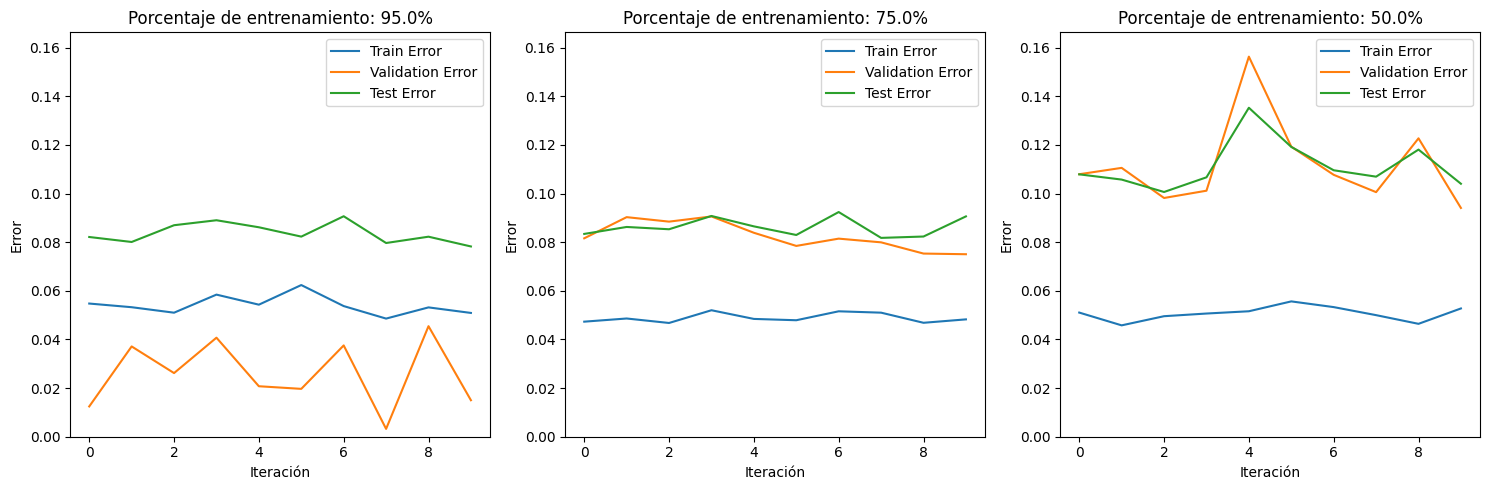

In [20]:
display(df)

# Para cada porcentaje mostrar la distribucion de los errores
def plot_ikeda(df):
    # Graficar la evolucion del promedio de errores, respecto al porcentaje de entrenamiento
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for i, p in enumerate(df.keys()):
        axs[i].plot(df[p]["train_error"], label="Train Error")
        axs[i].plot(df[p]["val_error"], label="Validation Error")
        axs[i].plot(df[p]["test_error"], label="Test Error")
        axs[i].set_title(f"Porcentaje de entrenamiento: {p*100}%")
        axs[i].set_xlabel("Iteración")
        axs[i].set_ylabel("Error")
        axs[i].legend()

    # Igualar el eje de las y para cada grafica
    y_max = df[0.95]["train_error"][0]
    for p in df.keys():
        y_max = max(y_max, max(df[p]["train_error"]), max(df[p]["val_error"]), max(df[p]["test_error"]))
    for ax in axs:
        ax.set_ylim(0, y_max+0.01)

    plt.tight_layout()
    plt.show()
plot_ikeda(df)

## Ejercicio 4

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


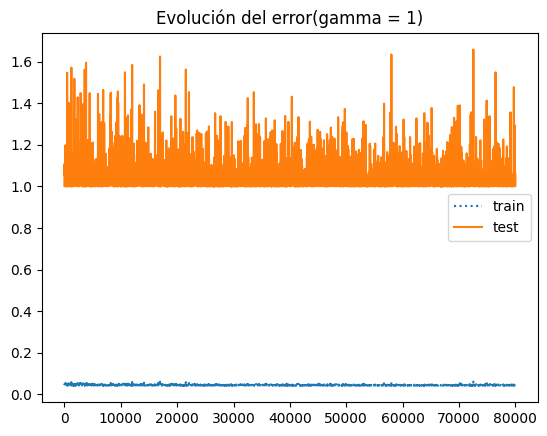

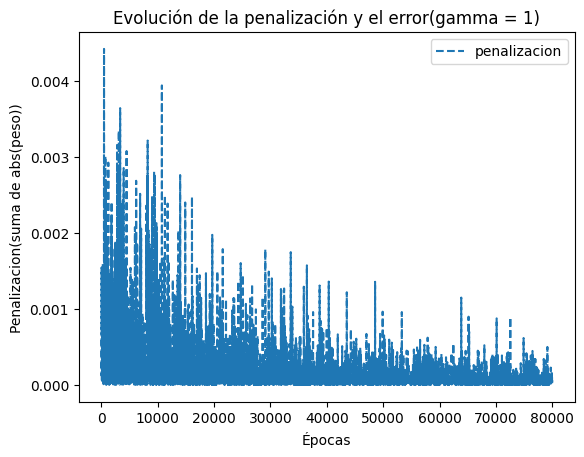

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


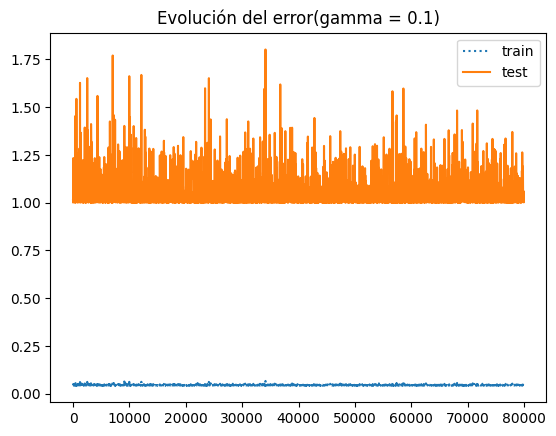

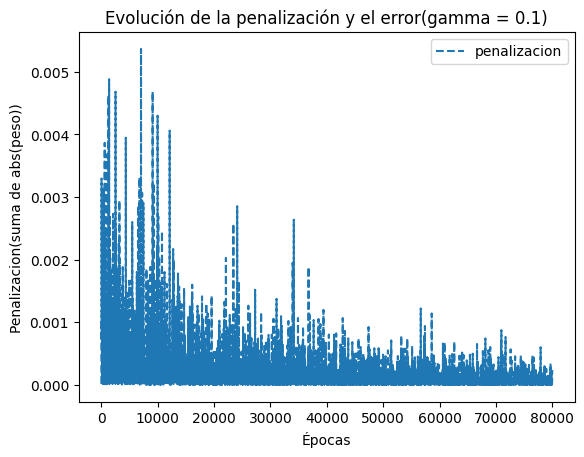

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


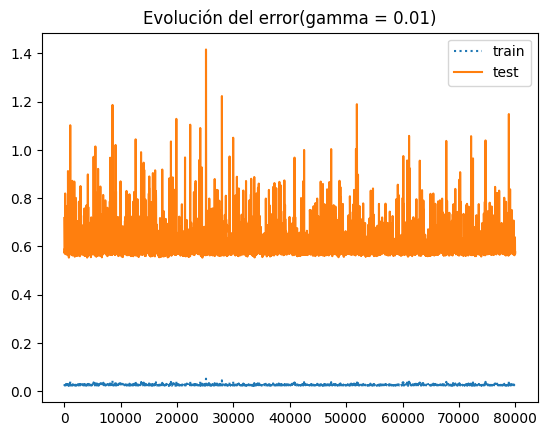

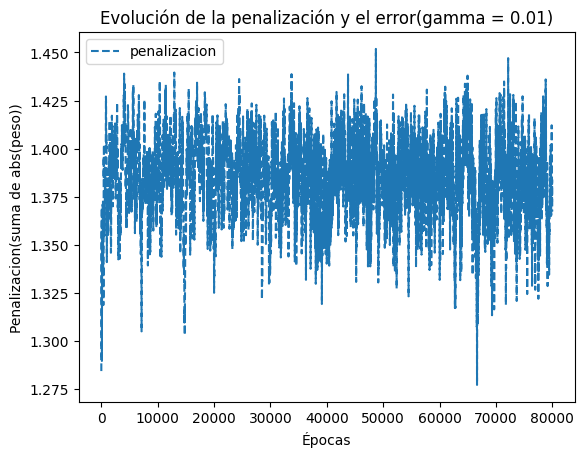

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the opti

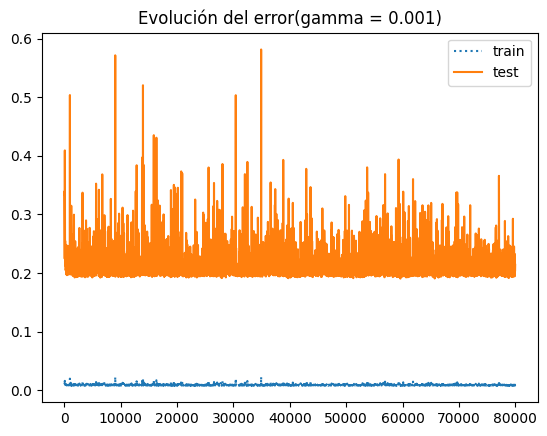

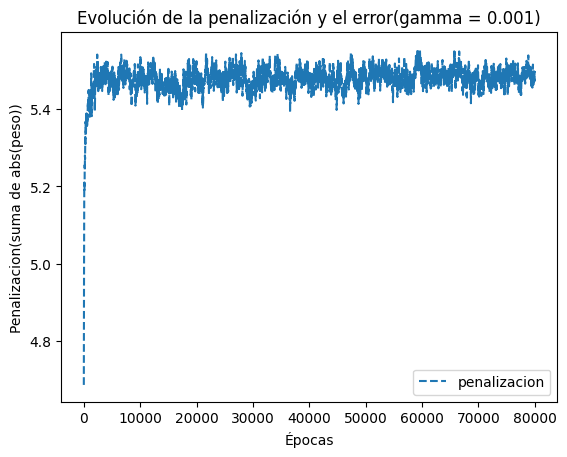

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the opti

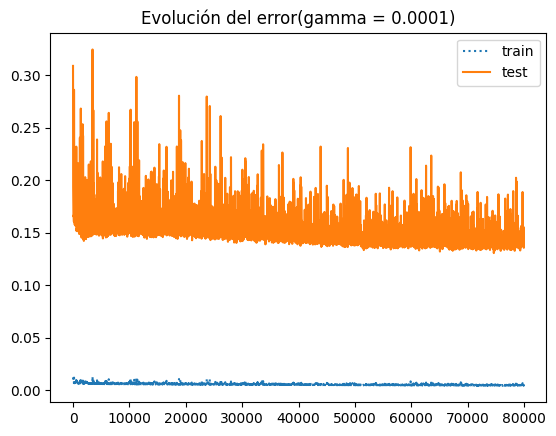

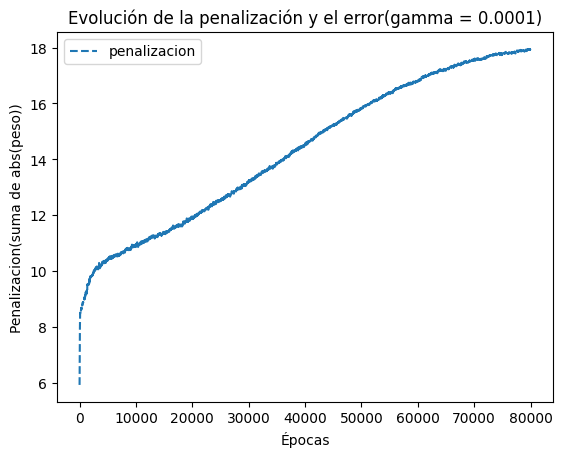

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the opti

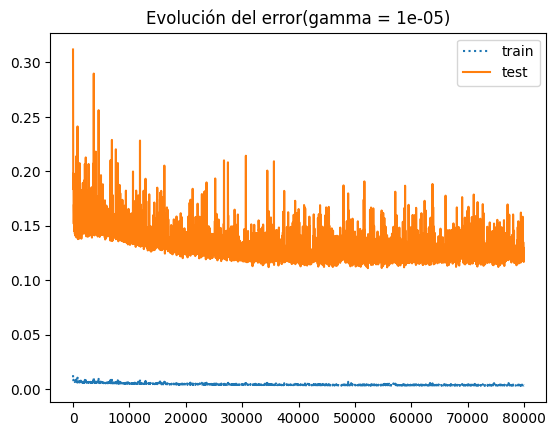

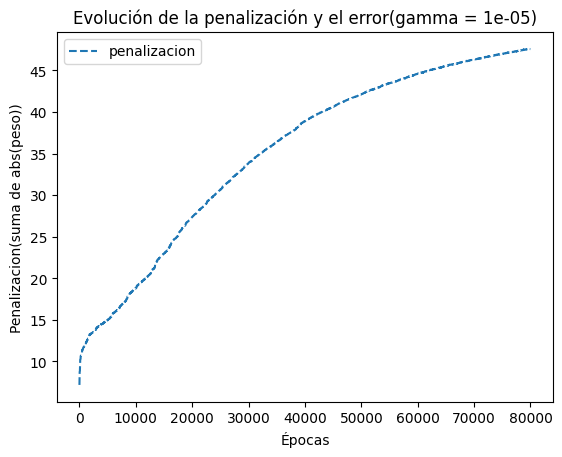

/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/don-berge/Documentos/IIA-TPS/TP4/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the opti

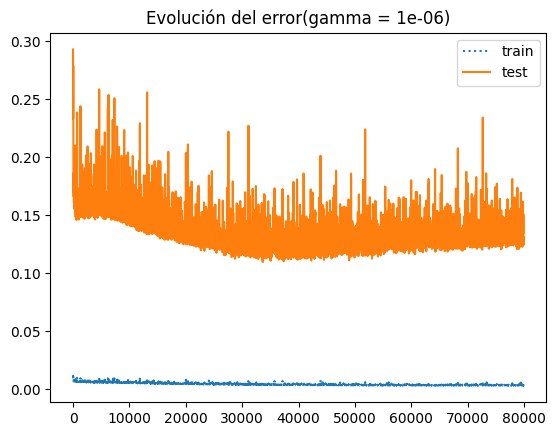

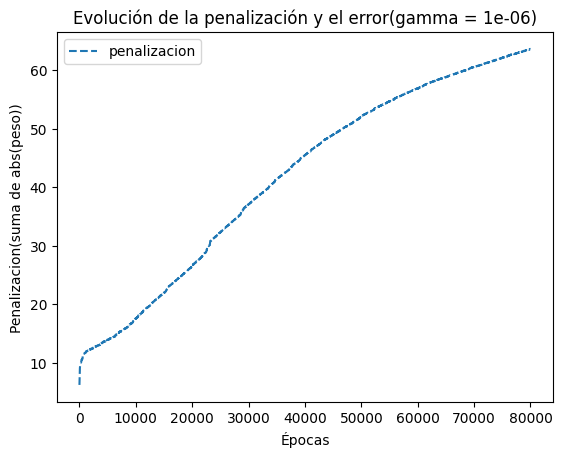

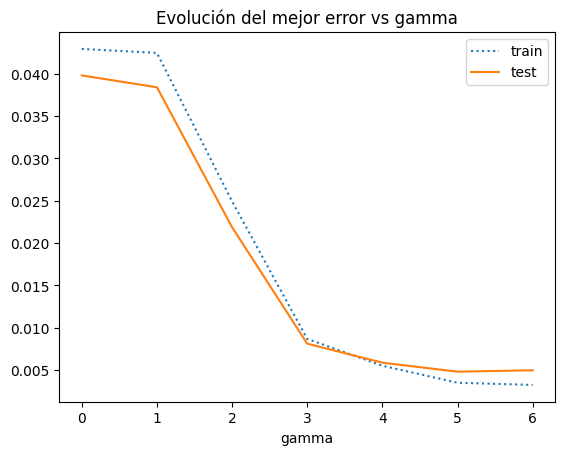

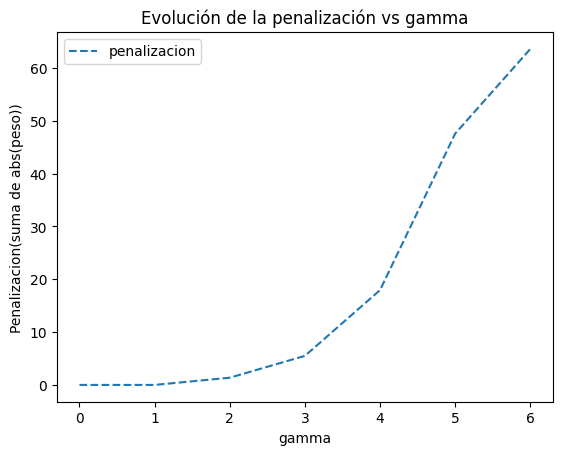

In [37]:
def calcular_penalizacion(coeff):
   return sum(np.square(w).sum() for w in coeff)

def entrenar_red(red: MLPClassifier | MLPRegressor,
                 X_train, y_train,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "super_epocas" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    penalizacion = []
    error_test = []
    best_val = 1.0
    best_red = red
    

    evaluaciones = super_epocas

    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(mean_squared_error(y_train, y_pred_train))
      # error de validacion
      error_test.append(1 - red.score(X_test, y_test))
      suma_pesos = calcular_penalizacion(red.coefs_)
      penalizacion.append(suma_pesos)
      if best_val > suma_pesos:
        best_val = suma_pesos
        best_red = deepcopy(red)
    return best_red, error_train, penalizacion, error_test

df = pd.read_csv("ssp.data", header=None)

X_train = df.iloc[:, :-1].values.tolist()
Y_train = df.iloc[:, -1].values.tolist()

df_test = pd.read_csv("ssp.test", header=None)

X_test = df_test.iloc[:, :-1].values.tolist()
Y_test = df_test.iloc[:, -1].values.tolist()

eta = 0.05
alfa = 0.3
super_epocas = 4000
sub_epocas = 20
N2 = 6

total_train_error = []
total_penalizacion = []
total_test_error = []

for e in range(7):
  gamma = 10**(-e)
  
  regr = MLPRegressor(hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', 
    alpha=gamma, batch_size=1, learning_rate='constant', 
    learning_rate_init=eta,momentum=alfa,nesterovs_momentum=False,tol=0.0,warm_start=True,max_iter=sub_epocas)
    
  best_fit, train_error, penalizacion, test_error = entrenar_red(regr, X_train, Y_train, X_test, Y_test)

  ans_train = best_fit.predict(X_train)
  ans_test = best_fit.predict(X_test)

  total_train_error.append(mean_squared_error(Y_train, ans_train))
  total_test_error.append(mean_squared_error(Y_test, ans_test))
  total_penalizacion.append(calcular_penalizacion(best_fit.coefs_))

  rango = np.array(range(super_epocas)) * sub_epocas
  plt.plot(rango, train_error, label="train", linestyle=":")
  plt.plot(rango, test_error, label="test", linestyle="-")
  plt.title("Evolución del error(gamma = {})".format(gamma))
  plt.legend()
  plt.show()


  plt.plot(rango, penalizacion, label="penalizacion", linestyle="--")
  plt.xlabel("Épocas")
  plt.ylabel("Penalizacion(suma de abs(peso))")
  plt.legend()
  plt.title("Evolución de la penalización y el error(gamma = {})".format(gamma))
  plt.show()

rango = range(7)
plt.plot(rango, total_train_error, label="train", linestyle=":")
plt.plot(rango, total_test_error, label="test", linestyle="-")
plt.xlabel("gamma")
plt.title("Evolución del mejor error vs gamma".format(gamma))
plt.legend()
plt.show()

plt.plot(rango, total_penalizacion, label="penalizacion", linestyle="--")
plt.title("Evolución de la penalización vs gamma")
plt.xlabel("gamma")
plt.ylabel("Penalizacion(suma de abs(peso))")
plt.legend()
plt.show()

